## Project Overview

This project analyzes banking transaction data to understand transaction behavior and identify potential indicators of unusual activity.

The analysis is based on the **Bank Transactions Dataset for Fraud Detection**, which contains **50,000 synthetic banking transactions** with 15 features describing transaction details, customer information, and technical metadata.

The goal of this project is to explore transaction patterns using **exploratory data analysis (EDA)** and understand how transaction characteristics vary across different variables such as transaction amount, channel, location, and customer attributes.

## Data Loading

In this step we load the dataset and inspect the structure of the data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


bank_transactions  = pd.read_csv("src/Data/bank_transactions.csv")
bank_transactions .head()


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,TX000001,AC00128,14.09,4/11/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21
1,TX000002,AC00455,376.24,6/27/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91
2,TX000003,AC00019,126.29,7/10/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35
3,TX000004,AC00070,184.50,5/5/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06
4,TX000005,AC00411,13.45,10/16/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40


### Step 1 — Understanding the data

In [2]:
# check head, for visual presentation of the table
bank_transactions.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,TX000001,AC00128,14.09,4/11/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21
1,TX000002,AC00455,376.24,6/27/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91
2,TX000003,AC00019,126.29,7/10/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35
3,TX000004,AC00070,184.50,5/5/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06
4,TX000005,AC00411,13.45,10/16/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40


In [3]:
# how much rows and columns we have
bank_transactions.shape

(50000, 15)

In [4]:
bank_transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionID        50000 non-null  str    
 1   AccountID            50000 non-null  str    
 2   TransactionAmount    50000 non-null  float64
 3   TransactionDate      50000 non-null  str    
 4   TransactionType      50000 non-null  str    
 5   Location             50000 non-null  str    
 6   DeviceID             50000 non-null  str    
 7   IP Address           50000 non-null  str    
 8   MerchantID           50000 non-null  str    
 9   Channel              50000 non-null  str    
 10  CustomerAge          50000 non-null  int64  
 11  CustomerOccupation   50000 non-null  str    
 12  TransactionDuration  50000 non-null  int64  
 13  LoginAttempts        50000 non-null  int64  
 14  AccountBalance       50000 non-null  float64
dtypes: float64(2), int64(3), str(10)
memory usage: 

In [5]:
bank_transactions.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000
mean,297.872214,44.647600,118.965320,1.12684,5122.738301
std,292.818888,17.800293,70.000681,0.60936,3904.266887
min,0.240000,18.000000,10.000000,1.00000,101.250000
25%,82.897500,27.000000,63.000000,1.00000,1508.720000
50%,209.355000,45.000000,111.000000,1.00000,4735.410000
75%,409.625000,59.000000,161.000000,1.00000,7713.670000
max,2060.590000,80.000000,300.000000,5.00000,14977.990000


#### Data Understanding Summary

1.The dataset contains 50,000 banking transactions with 15 features describing transaction details, customer information, and technical metadata.
2.Initial inspection shows that the dataset does not contain missing values.
3.The dataset includes both numerical variables (transaction amount, account balance, customer age, transaction duration, login attempts) and categorical variables (transaction type, location, channel, device ID, customer occupation).
4.The average transaction amount is approximately 298, with a maximum value exceeding 2000, indicating the presence of potentially large transactions.
5.Customer ages range from 18 to 80, with an average age of around 45 years.
6.Login attempts range from 1 to 5, suggesting that repeated login attempts may be an important indicator of suspicious activity.

##### Problems
One issue identified during data inspection is that the TransactionDate column is currently stored as a string and will need to be converted to datetime format for time-based analysis.

### Step 2 - Data Cleaning
In this step we are cleaning data.


In [6]:
# Fix TransactionDate format. The TransactionDate column was stored as a string. 
# It was converted to datetime format to enable time-based analysis.
bank_transactions["TransactionDate"] = pd.to_datetime(bank_transactions["TransactionDate"], format="mixed")


In [7]:
# The dataset contains no missing values and no duplicate rows.  Additionally, the number of rows equals
# the number of unique TransactionID values, confirming that each transaction is uniquely identified.
print(bank_transactions.duplicated().sum())
print("----------------------------------")
print(bank_transactions.isnull().sum())
print("-----------------------------------")
print(bank_transactions["TransactionID"].nunique())

0
----------------------------------
TransactionID          0
AccountID              0
TransactionAmount      0
TransactionDate        0
TransactionType        0
Location               0
DeviceID               0
IP Address             0
MerchantID             0
Channel                0
CustomerAge            0
CustomerOccupation     0
TransactionDuration    0
LoginAttempts          0
AccountBalance         0
dtype: int64
-----------------------------------
50000


### Step 3 - Exploratory Data Analysis (EDA)
In this section we explore the dataset to understand the distribution of features, 
identify potential anomalies, and detect patterns that may indicate suspicious transactions.

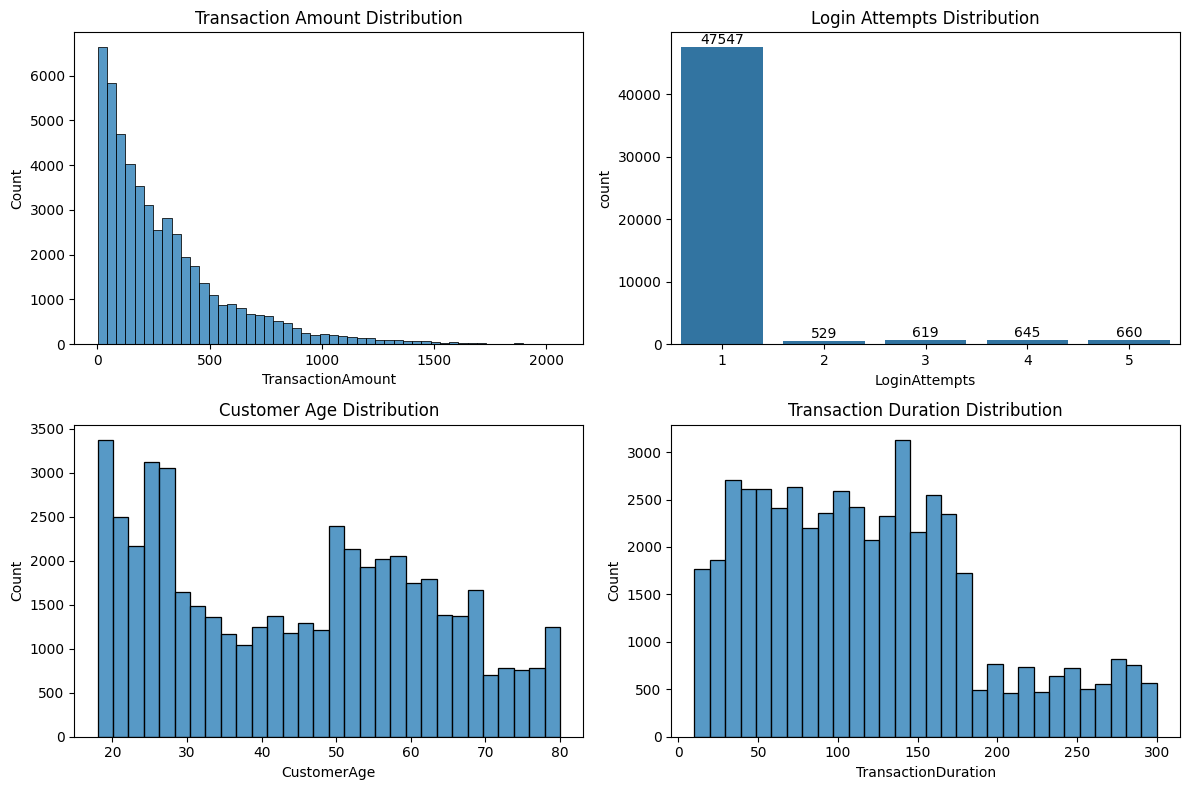

In [8]:

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# TransactionAmount
sns.histplot(bank_transactions["TransactionAmount"], bins=50, ax=axes[0,0])
axes[0,0].set_title("Transaction Amount Distribution")


# LoginAttempts
sns.countplot(x="LoginAttempts", data=bank_transactions, ax=axes[0,1])
axes[0,1].set_title("Login Attempts Distribution")

for p in axes[0,1].patches:
    axes[0,1].annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

# CustomerAge
sns.histplot(bank_transactions["CustomerAge"], bins=30, ax=axes[1,0])
axes[1,0].set_title("Customer Age Distribution")

# TransactionDuration
sns.histplot(bank_transactions["TransactionDuration"], bins=30, ax=axes[1,1])
axes[1,1].set_title("Transaction Duration Distribution")

plt.tight_layout()
plt.show()

The basic feature distributions appear realistic and consistent. 
Most transactions involve relatively small amounts, the majority of operations require only one login attempt, and customer ages fall within a typical adult range. 
No obvious anomalies were detected in these variables.

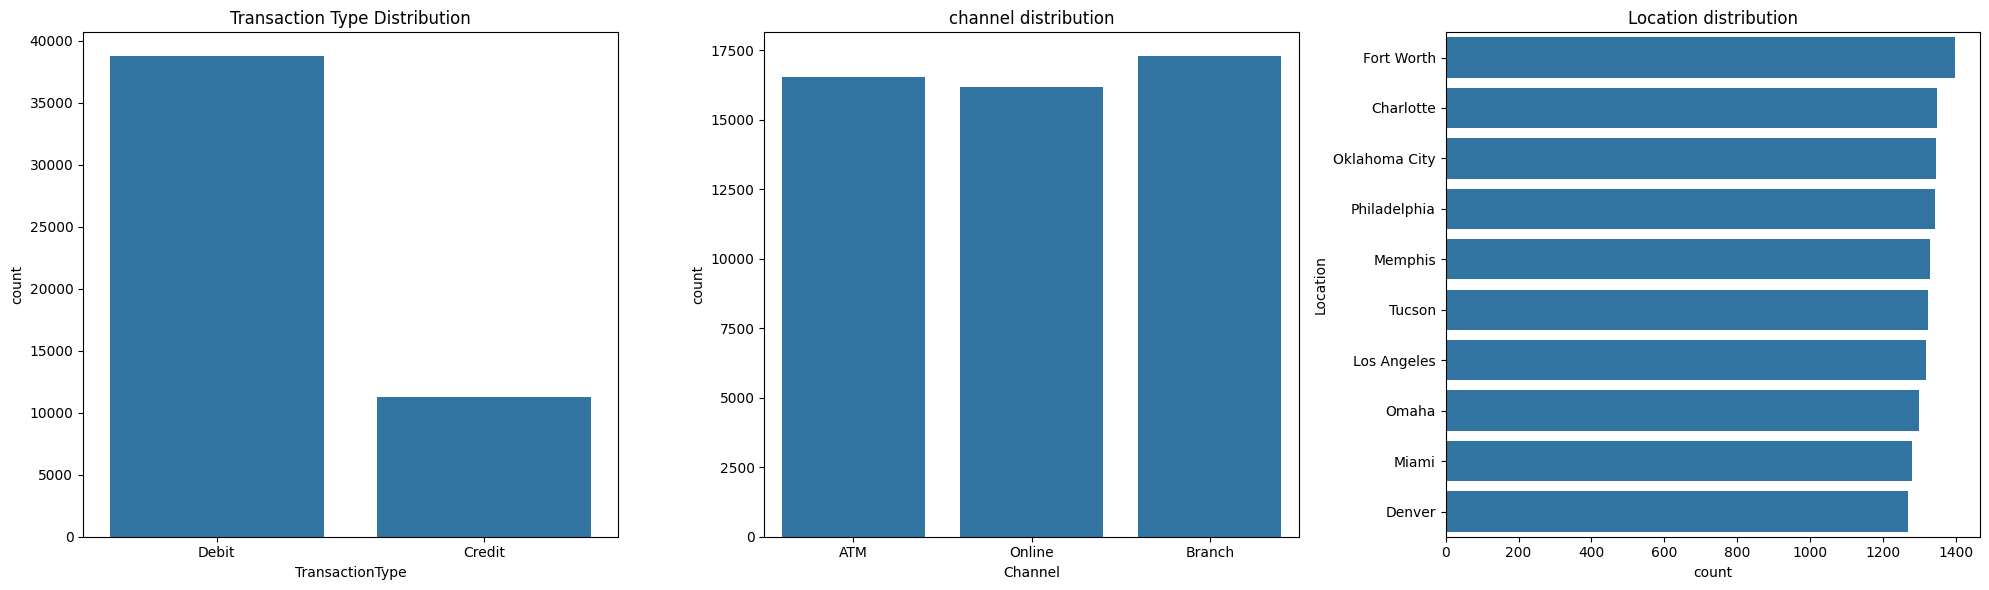

In [9]:
fig, axes = plt.subplots(1,3, figsize=(20,6))

sns.countplot(x ="TransactionType", data=bank_transactions, ax=axes[0])
axes[0].set_title("Transaction Type Distribution")

sns.countplot(x="Channel", data=bank_transactions, ax=axes[1])
axes[1].set_title("channel distribution")


top_locations = bank_transactions["Location"].value_counts().nlargest(10).index
sns.countplot(y="Location", data=bank_transactions,order=top_locations, ax=axes[2])
axes[2].set_title("Location distribution")

plt.tight_layout()


The analysis of categorical features shows that debit transactions dominate the dataset, accounting for the majority of operations.

Transaction activity is relatively evenly distributed across different channels (ATM, Online, and Branch), indicating balanced usage of banking services.

Similarly, the geographic distribution of transactions appears fairly uniform across the listed locations, suggesting that the dataset does not exhibit strong regional concentration.

Overall, no obvious anomalies are visible at the individual feature level. Further analysis will focus on relationships between variables to identify potentially suspicious patterns.

##### 3.1 Analysing relationships

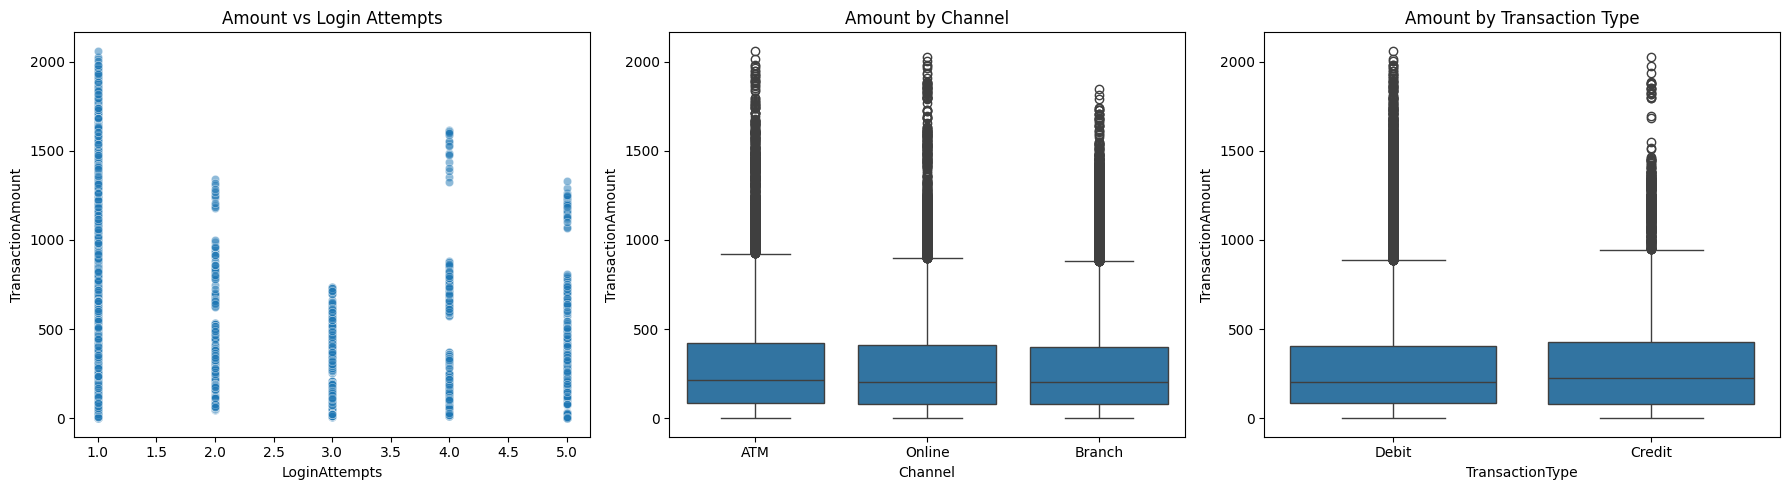

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.scatterplot(
    x="LoginAttempts",
    y="TransactionAmount",
    data=bank_transactions,
    ax=axes[0],
    alpha=0.5
)
axes[0].set_title("Amount vs Login Attempts")

sns.boxplot(
    x="Channel",
    y="TransactionAmount",
    data=bank_transactions,
    ax=axes[1]
)
axes[1].set_title("Amount by Channel")

sns.boxplot(
    x="TransactionType",
    y="TransactionAmount",
    data=bank_transactions,
    ax=axes[2]
)
axes[2].set_title("Amount by Transaction Type")

plt.tight_layout()
plt.show()

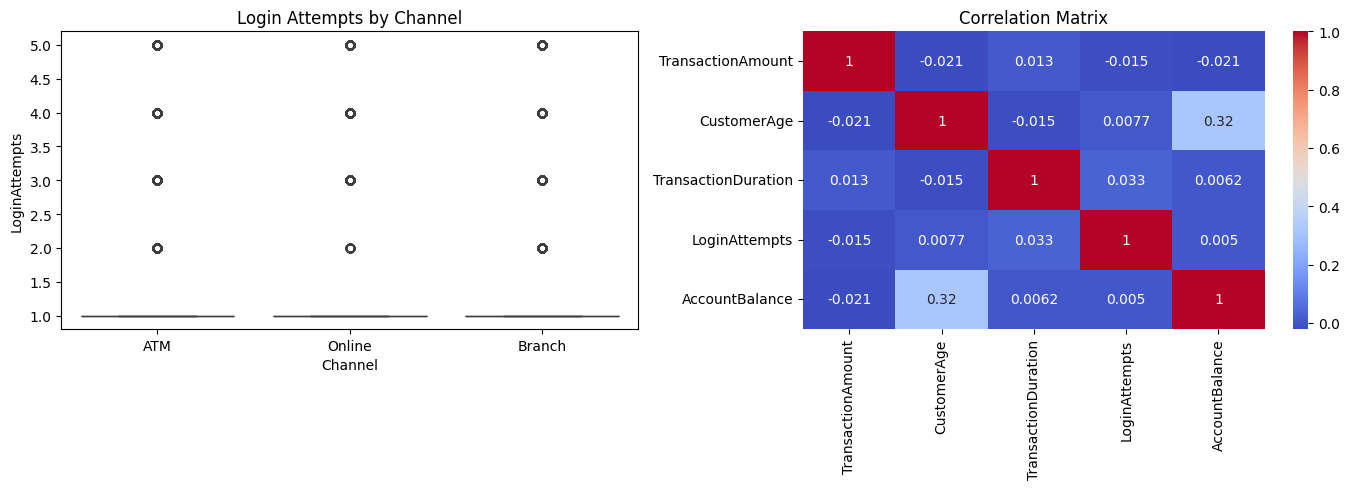

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(
    x="Channel",
    y="LoginAttempts",
    data=bank_transactions,
    ax=axes[0]
)
axes[0].set_title("Login Attempts by Channel")

numeric_cols = [
    "TransactionAmount",
    "CustomerAge",
    "TransactionDuration",
    "LoginAttempts",
    "AccountBalance"
]

corr = bank_transactions[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    ax=axes[1]
)
axes[1].set_title("Correlation Matrix")

plt.tight_layout()
plt.show()



The relationship analysis shows that most variables in the dataset are weakly correlated. 
Transaction amounts do not appear to depend strongly on login attempts, transaction type, or transaction channel.

Most transactions occur after a single login attempt, and this behavior is consistent across all channels. 
Additionally, transaction amount distributions are similar across different transaction types and banking channels.

The correlation analysis confirms that there are no strong linear relationships between the numerical features. 
The only moderate correlation is observed between customer age and account balance, which is expected as older customers tend to have higher balances.

## Conclusion

This project demonstrates how exploratory data analysis can be used to understand banking transaction behavior.

Although the dataset does not include a fraud label, the analysis highlights several behavioral characteristics of financial transactions and provides a foundation for further work in anomaly detection or fraud analysis.